# Performance notes

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import pylandstats as pls

This notebook will serve to compare the performance of PyLandStats with those of FRAGSTATS (v4.2) [1] and [the R package landscapemetrics](https://github.com/r-spatialecology/landscapemetrics) (v1.0) [2]. As a benchmark, we will compute [all the metrics implemented in PyLandStats](https://pylandstats.readthedocs.io/en/latest/landscape.html#list-of-implemented-metrics) (note however that landscapemetrics only computes the mean, standard deviation and coefficient of variation of each patch metric, whereas PyLandStats and FRAGSTATS further compute the area-weighted mean, median and range of each patch metric).

The FRAGSTATS and landscapemetrics execution times discussed below have been obtained in an Ubuntu desktop computer with the following processor:

```bash
$ cat /proc/cpuinfo  | grep 'name'| uniq
model name : Intel(R) Xeon(R) CPU E5-1620 0 @ 3.60GHz
```

**ACHTUNG**: the PyLandStats cells of this notebook have since been re-executed on a different (and slower) machine, namely an `Intel(R) Core(TM) i7-10510U CPU @ 1.80GHz`. Furthermore, PyLandStats has since implemented the core area metrics, which did not exist when the reference execution times were measured, and which the benchmark cells below therefore also compute. Accordingly, the bar plots below show the values as originally measured (i.e., all three in the same computer and over the same set of metrics), whereas the outputs of the benchmark cells reflect the current PyLandStats on the slower machine.

The execution times for the FRAGSTATS software have been obtained by manually selecting the metrics in the graphical user interface (run in Ubuntu by means of the [WineHQ](https://wiki.winehq.org/Ubuntu) compatibility layer for Windows applications).

On the other hand, the execution times for the landscapemetrics package have been obtained by running [a dedicated R script](https://github.com/martibosch/pylandstats-notebooks/tree/master/other/metricsBenchmark.R) in a Docker instance of the image [`rocker/geospatial`](https://hub.docker.com/r/rocker/geospatial/). Note that such Docker image does not include the landscapemetrics package out of the box, but it can be easily installed as in `install.packages("landscapemetrics")`.

## Benchmarks

Let us first define a function to make a very simple benchmark plot:

In [2]:
def benchmark_plot(execution_times):
    """Plot the execution times of each library as a bar plot."""
    x = np.arange(3)
    plt.bar(x, execution_times)
    plt.xticks(x, ["FRAGSTATS", "landscapemetrics", "PyLandStats"])

### Benchmark 1: Canton of Vaud

We will first measure the execution times for the extract of the Canton of Vaud (Switerland) derived from the [CORINE Land Cover dataset](https://land.copernicus.eu/pan-european/corine-land-cover) of the year 2000, reclassified into urban and non-urban classes.

In [3]:
ls = pls.Landscape("../data/raw/clc/vaud_g100_clc00_V18_5.tif", res=(100, 100))

print(
    f"Landscape size [pixels]: {ls.landscape_arr.shape[0]}x{ls.landscape_arr.shape[1]}"
)
print(f"Number of classes: {len(ls.classes)}")

Landscape size [pixels]: 889x916
Number of classes: 2


In [4]:
%%time
patch_df = ls.compute_patch_metrics_df()
class_df = ls.compute_class_metrics_df()
landscape_df = ls.compute_class_metrics_df()

CPU times: user 3.18 s, sys: 337 ms, total: 3.52 s
Wall time: 3.29 s


The execution times for this first benchmark are of 610 ms with FRAGSTATS and 14.27 s with landscapemetrics. In the same computer and over the same set of metrics, the execution time of the above cell was of 969 ms, which gives us the following plot (see the note above on how the cell outputs relate to these values):

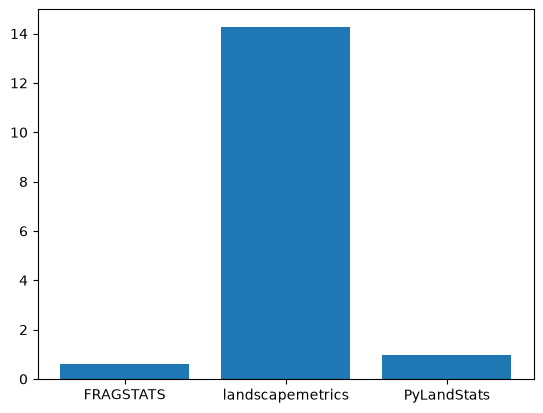

In [5]:
benchmark_plot([0.61, 14.27, 0.969])

### Benchmark 2: Cantons of Bern and Valais

We will now measure the execution times for an extract of the cantons of Bern and Valais (Switzerland), also derived from the CORINE Land Cover dataset of the year 2000, however, this time without reclassifying the land cover classes.

In [6]:
ls = pls.Landscape("../data/raw/clc/bern_valais_g100_clc00.tif", res=(100, 100))

print(
    f"Landscape size [pixels]: {ls.landscape_arr.shape[0]}x{ls.landscape_arr.shape[1]}"
)
print(f"Number of classes: {len(ls.classes)}")

Landscape size [pixels]: 1640x1319
Number of classes: 28


In [7]:
%%time
patch_df = ls.compute_patch_metrics_df()
class_df = ls.compute_class_metrics_df()
landscape_df = ls.compute_class_metrics_df()

/home/martibosch/data-science/pylandstats-notebooks/src/pylandstats/src/pylandstats/landscape.py:1309: RuntimeWarning: Class 10 has less than 2 patches. Euclidean-nearest-neighbor might contain nan values
  warnings.warn(


/home/martibosch/data-science/pylandstats-notebooks/src/pylandstats/src/pylandstats/landscape.py:1324: RuntimeWarning: Class 10 has less than 2 patches. Euclidean-nearest-neighbor might contain nan values
  warnings.warn(
/home/martibosch/data-science/pylandstats-notebooks/src/pylandstats/src/pylandstats/landscape.py:1324: RuntimeWarning: Class 10 has less than 2 patches. Euclidean-nearest-neighbor might contain nan values
  warnings.warn(


/home/martibosch/data-science/pylandstats-notebooks/src/pylandstats/src/pylandstats/landscape.py:1324: RuntimeWarning: Class 10 has less than 2 patches. Euclidean-nearest-neighbor might contain nan values
  warnings.warn(
/home/martibosch/data-science/pylandstats-notebooks/src/pylandstats/src/pylandstats/landscape.py:1324: RuntimeWarning: Class 10 has less than 2 patches. Euclidean-nearest-neighbor might contain nan values
  warnings.warn(


CPU times: user 1min 1s, sys: 17.9 s, total: 1min 19s
Wall time: 1min 15s


The execution times for this second benchmark are of 33.31 s with FRAGSTATS and 553.45 s (i.e., 9 min 13 s) with landscapemetrics. In the same computer and over the same set of metrics, the execution time of the above cell was of 32.9 s, which gives us the following plot:

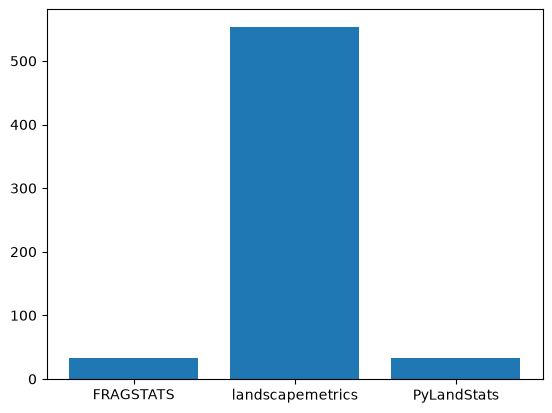

In [8]:
benchmark_plot([33.31, 553.45, 32.9])

## PyLandStats performance and implementation details

In PyLandStats, each landscape is a Python object, upon which Python properties are employed to cache results that are computationally expensive to obtain and can later be accessed in constant (almost immediate) time. This mechanism is exploited to cache intermediate results that are later used to compute the metrics. More precisely, instances of the Landscape class cache the list of patches, each with its respective LULC class, area, perimeter and nearest-neigbhor distance, as well as the pixel adjacency matrix, i.e., the number of adjacencies between pixels of each landscape class (including adjacencies between pixels of the same class).

To illustrate such mechanism, let us re-instantiate the landscape for the Cantons of Bern and Valais:

In [9]:
ls = pls.Landscape("../data/raw/clc/bern_valais_g100_clc00.tif", res=(100, 100))

Right after the instantiation of a landscape object, none of the attributes listed below are defined:

In [10]:
print(hasattr(ls, "_cached_num_patches_dict"))
print(hasattr(ls, "_cached_patch_area_ser"))
print(hasattr(ls, "_cached_patch_perimeter_ser"))

False
False
False


Nevertheless, after computing an area-related, e.g., `area`:

In [11]:
%%time
area = ls.area()

CPU times: user 774 ms, sys: 852 μs, total: 775 ms
Wall time: 777 ms


the Python properties defined in the `Landscape` class will set the `_cached_num_patches_dict` (number of patches of each LULC class) and `_cached_patch_area_ser` (area of each patch) attributes, which can hereafter be accessed in constant (almost immediate) time:

In [12]:
ls._cached_num_patches_dict

{np.uint8(1): 7,
 np.uint8(2): 427,
 np.uint8(3): 52,
 np.uint8(4): 2,
 np.uint8(6): 11,
 np.uint8(7): 8,
 np.uint8(9): 2,
 np.uint8(10): 1,
 np.uint8(11): 14,
 np.uint8(12): 191,
 np.uint8(15): 31,
 np.uint8(16): 11,
 np.uint8(18): 473,
 np.uint8(20): 84,
 np.uint8(21): 39,
 np.uint8(23): 89,
 np.uint8(24): 533,
 np.uint8(25): 579,
 np.uint8(26): 329,
 np.uint8(27): 209,
 np.uint8(29): 72,
 np.uint8(30): 19,
 np.uint8(31): 218,
 np.uint8(32): 490,
 np.uint8(34): 151,
 np.uint8(35): 6,
 np.uint8(40): 8,
 np.uint8(41): 31}

In [13]:
ls._cached_patch_area_ser.head()

0     590000
1     950000
2     710000
3    1110000
4     500000
Name: area, dtype: int64

Similarly, after computing a perimeter-related metric, e.g., `perimeter_area_ratio`, the attribute `_cached_patch_perimeter_ser` (perimeter of each patch) will be set, and hereafter accessible in constant time:

In [14]:
%%time
perimeter = ls.perimeter()

CPU times: user 676 ms, sys: 23 μs, total: 676 ms
Wall time: 676 ms


In [15]:
ls._cached_patch_perimeter_ser.head()

0    5200
1    5200
2    6000
3    8600
4    4800
Name: perimeter, dtype: int64

Note that after the area and perimeter of each patch are cached, the computation of other area, edge and shape metrics is orders of magnitude faster

In [16]:
%%time
frac = ls.fractal_dimension()

CPU times: user 1.09 ms, sys: 26 μs, total: 1.12 ms
Wall time: 1.06 ms


And the same applies to the computations that require the class adjacency matrix

In [17]:
hasattr(ls, "_cached_adjacency_df")

False

In [18]:
%%time
ed = ls.edge_density()

CPU times: user 49.3 ms, sys: 0 ns, total: 49.3 ms
Wall time: 56.7 ms


In [19]:
ls._cached_adjacency_df.head()

1.0      2.0     3.0    4.0     6.0    7.0    9.0    \
direction  class_val                                                        
horizontal 1.0        818.0    140.0    13.0   10.0     0.0    0.0    0.0   
           2.0        140.0  72852.0   520.0   28.0    23.0    2.0    0.0   
           3.0         13.0    520.0  4598.0    5.0     4.0    0.0    3.0   
           4.0         10.0     28.0     5.0   98.0     0.0    0.0    0.0   
           6.0          0.0     23.0     4.0    0.0  1322.0    0.0    0.0   

                      10.0   11.0    12.0   ...  27.0   29.0   30.0   31.0   \
direction  class_val                        ...                               
horizontal 1.0          0.0    0.0     0.0  ...    0.0    0.0    0.0    0.0   
           2.0         22.0  102.0  6583.0  ...   30.0    4.0    1.0    4.0   
           3.0          2.0   36.0   356.0  ...    2.0    0.0    0.0    0.0   
           4.0          0.0    0.0     0.0  ...    0.0    0.0    0.0    0.0   
           6.0          0.0    0.0    77.0  ...    0.0    0.0    0.0    0.0   

                      32.0   34.0   35.0   40.0   41.0   255.0  
direction  class_val                                            
horizontal 1.0          0.0    0.0    0.0    0.0    0.0    0.0  
           2.0         21.0    0.0   13.0   72.0  295.0  119.0  
           3.0          0.0    0.0    0.0    1.0    7.0    8.0  
           4.0          0.0    0.0    0.0    0.0    0.0    0.0  
           6.0          0.0    0.0    0.0    0.0    0.0    0.0  

[5 rows x 29 columns]

In [20]:
%%time
lsi = ls.landscape_shape_index()

CPU times: user 4.4 ms, sys: 373 μs, total: 4.77 ms
Wall time: 4.66 ms


But it is when it comes to the computation of the inter-patch nearest-neighbor distances (the most computationally expensive task) that performance gains become more significant:

In [21]:
hasattr(ls, "_cached_patch_euclidean_nearest_neighbor_ser")

False

In [22]:
%%time
enn = ls.euclidean_nearest_neighbor()

CPU times: user 6.12 s, sys: 405 ms, total: 6.52 s
Wall time: 2.59 s


/home/martibosch/data-science/pylandstats-notebooks/src/pylandstats/src/pylandstats/landscape.py:1309: RuntimeWarning: Class 10 has less than 2 patches. Euclidean-nearest-neighbor might contain nan values
  warnings.warn(


In [23]:
ls._cached_patch_euclidean_nearest_neighbor_ser.head()

0    23584.952830
1      360.555128
2      316.227766
3      316.227766
4    18112.150618
Name: euclidean_nearest_neighbor, dtype: float64

In [24]:
%%time
enn_l_sd = ls.euclidean_nearest_neighbor_sd()

CPU times: user 2.07 ms, sys: 18 μs, total: 2.09 ms
Wall time: 1.88 ms


The euclidean nearest-neighbor used to be by far the main performance bottleneck of PyLandStats, i.e., 26.6 s out of the 32.9 s required to compute all the metrics in the original benchmark above. It is now computed by querying a single k-d tree built with the pixels of all the patches of a class (instead of building one k-d tree per patch), which is why the cell above only takes a few seconds.

The bottleneck is now the core area metrics: computing every metric of the second benchmark except the core area ones takes 8.82 s in the machine on which this notebook has been re-executed, against the 1 min 15 s that computing all of them takes. Note also that, since that machine is slower than the one of the reference execution times above, the 8.82 s are not directly comparable to the 32.9 s of the original benchmark, yet they are measured over the same set of metrics.

It is therefore recommended that analysis cases which do not require the core area (or the euclidean nearest-neighbor) metrics avoid computing them by making use of the `metrics` keyword argument of the `compute_patch_metrics_df`, `compute_class_metrics_df` and `compute_landscape_metrics_df` methods.

## References

1. Kevin McGarigal, Sam A Cushman, and Eduard Ene. Fragstats v4: spatial pattern analysis program for categorical and continuous maps. Computer software program produced by the authors at the University of Massachusetts, Amherst. Available at: http://www.umass.edu/landeco/research/fragstats/fragstats.html, 2012.
2. Maximilian HK Hesselbarth, Marco Sciaini, Kimberly A With, Kerstin Wiegand, and Jakub Nowosad. landscapemetrics: an open-source r tool to calculate landscape metrics. Ecography, 2019.